# PAC-Learning Validation — 1D $\mathbb{Z}_2$ Schwinger Model

## From $d = O(\log n)$ to $d = O(\text{poly}(n))$

This notebook implements the Schwinger model extension proposed in the BRGD25 slides:
the 1D $\mathbb{Z}_2$ Lattice Gauge Theory with **spatially-dependent coupling strength**.
This moves the learning problem from the $d=O(\log n)$ regime (where quantum advantage
is proven) toward the $d=O(\text{poly}(n))$ regime (where the method is expected to fail).

---

## Model

$$H = m\sum_i(-1)^i Z_{m_i} + \sum_i g_i\, X_{m_i}Z_{l_i}X_{m_{i+1}} + h\sum_i X_{l_i}$$

| Symbol | Role | Status |
|---|---|---|
| $m$ | staggered fermion mass | **known** |
| $h$ | electric field coupling | **known** |
| $g_i$ | hopping amplitude on link $i$ | **unknown** — spatially varying |
| $x$ | initial gauge field configuration $\in\{0,1\}^{N-1}$ | input variable |

**Qubit layout** for $N=3$ matter sites (5 qubits total, interlaced matter/link):
```
qubit: 0      1       2      3       4
role:  m₀  link₀₁   m₁  link₁₂   m₂
```

---

## Why this is harder — and in what sense it challenges the framework

| Property | TFIM (d=1) | Model 4 (d=2) | Schwinger (d=N−1) |
|---|---|---|---|
| Unknown params | $\beta$ (uniform X field) | $\alpha, \beta$ | $g_0, g_1, \ldots, g_{N-2}$ |
| d_params | 1 | 2 | **N−1 = poly(n)** |
| Fourier modes | $(4nr+1)$ | $(4r+1)^2$ | $(4r+1)^{N-1}$ — **exponential in N** |
| Upload Pauli | single-body $X_i$ | $ZZ$ + $X_i$ | **3-body** $X_{m_i}Z_{l_i}X_{m_{i+1}}$ |
| Input space | $2^{C(n,2)}$ graph topologies | same | $2^{N-1}$ **gauge configurations** |
| Gauge constraint | none | none | **Gauss's law** must be respected |

The 3-body Pauli upload gate means the D block computes parity over **three** qubits
(matter-link-matter), making the frequency register sensitive to the correlated
motion of fermions and gauge fields simultaneously.  The slides hypothesise that
BRGD25 will either fail at large $N$ (high-frequency Fourier content) or find
an unexpected sparse structure that keeps it tractable.

---

## Observables

| Observable | Physical meaning | Pauli string |
|---|---|---|
| Staggered magnetisation $\langle M_\mathrm{stag}\rangle$ | Fermion condensate order parameter | $\frac{1}{3}(Z_0 - Z_2 + Z_4)$ |
| Electric flux $\langle E_{11}\rangle$ | Gauge field on link 1-1 | $X_1$ (link qubit) |
## Bug fixes applied in this version

| Fix | Location | Description |
|---|---|---|
| **Bug 1** | `H_schwinger`, `exact_obs` | `H_schwinger` now takes `x_mask` and only includes active-link coupling terms. `exact_obs` passes `x_mask` to it. Previously the exact reference used the full Hamiltonian for all x_masks, causing errors up to ±0.55 at long times for inactive-link states. |
| **Concern 2** | Cells 8 & 10 | `TEST_X_Z0=[1,0]` and `TEST_X_FLUX=[1,1]` are now separate variables. Cell 10 no longer silently overwrites the global `TEST_X`, which previously corrupted the visualisation when cells were re-run. |
| **Cell 14** | Summary cell | `extract_b_l_schwinger` call fixed to pass `PAULI_Z0_STR` instead of the float `1.0`. |
| **Cell 19** | N=4 feature extraction | Switched `get_lgt_aup_statevector` to use `build_lgt_expectation_value_extraction_circuit` (fast explicit adjoint) instead of `qc_forward.inverse()` (slow unitary decomposition). |



## 1 — Imports & parameters

In [2]:
import sys, os, time
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy.linalg import expm
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp
from sklearn.linear_model import Lasso

from src.quantum_routines import CircuitBuilder

# ── Model parameters ──────────────────────────────────────────────────────────
N_MATTER    = 3      # matter sites → 5 qubits (2N-1)
N_QUBITS    = 2 * N_MATTER - 1   # = 5
N_LINKS     = N_MATTER - 1       # = 2 (d_params = 2)

# Known parameters (fixed, not learned)
MASS        = 0.5    # staggered fermion mass m
H_ELEC      = 0.3   # electric field coupling h

# Unknown parameters (what the learner must infer from training data)
TRUE_G      = [1.0, 0.7]   # [g_0, g_1] — spatially-varying hopping amplitudes

# Learning setup
R_STEPS     = 4      # Trotter steps (keep small: 5-qubit circuit is expensive)
LASSO_ALPHA = 1e-5
EPSILON_B   = 0.0
T_VALUES    = np.linspace(0, 3, 13)

# Input space: gauge field configurations x ∈ {0,1}^{N-1}
# x_state = binary string of length N_LINKS ('00','01','10','11' for N=3)
# NEW CORRECTED VERSION (Lists of integers):
ALL_X_STATES = [[int(b) for b in format(k, f'0{N_LINKS}b')] for k in range(2**N_LINKS)]

# Test state: [1, 0] (link 0 flipped, link 1 unflipped) — unseen in training
TEST_X      = [1, 0]
TRAIN_X     = [x for x in ALL_X_STATES if x != TEST_X]  # 3 training states
NUM_TRAIN   = len(TRAIN_X)

builder = CircuitBuilder()

print(f'1D Z₂ Schwinger model:  N_matter={N_MATTER},  N_qubits={N_QUBITS}')
print(f'  Known:    m={MASS},  h={H_ELEC}')
print(f'  Unknown:  g = {TRUE_G}  (d={N_LINKS} parameters)')
print(f'  Input space: {ALL_X_STATES}  (gauge field configurations)')
print(f'  Training: {TRAIN_X}  →  Test: {TEST_X}')
print(f'  r={R_STEPS} Trotter steps,  LASSO_alpha={LASSO_ALPHA}')

1D Z₂ Schwinger model:  N_matter=3,  N_qubits=5
  Known:    m=0.5,  h=0.3
  Unknown:  g = [1.0, 0.7]  (d=2 parameters)
  Input space: [[0, 0], [0, 1], [1, 0], [1, 1]]  (gauge field configurations)
  Training: [[0, 0], [0, 1], [1, 1]]  →  Test: [1, 0]
  r=4 Trotter steps,  LASSO_alpha=1e-05


## 2 — Hamiltonian & reference functions

In [3]:
def H_schwinger(x_mask, g_list, h_elec):
    """Full Hamiltonian for the 1D Z₂ Schwinger model.

    H = m*sum_i (-1)^i Z_{matter_i}
      + sum_{i: x_mask[i]=1} g_i * X_{m_i} Z_{l_i} X_{m_{i+1}}
      + h * sum_i X_{link_i}

    FIX (Bug 1): x_mask now controls which coupling terms are included.
    Only active links (x_mask[i]=1) contribute to the gauge coupling.
    Qubit layout (interlaced, Qiskit little-endian):
      qubit 0: matter 0,  qubit 1: link 0-1,  qubit 2: matter 1,
      qubit 3: link 1-2,  qubit 4: matter 2
    """
    n = N_QUBITS
    ops, vals = [], []

    # Staggered mass: m*(-1)^i * Z on matter site i (qubit 2i)
    for i, mq in enumerate(range(0, n, 2)):
        p = ['I']*n; p[n-1-mq] = 'Z'
        ops.append(''.join(p)); vals.append((-1)**i * MASS)

    # Gauge coupling: g_i * X_{m_i} Z_{l_i} X_{m_{i+1}}  — ONLY for active links
    for i in range(N_LINKS):
        if x_mask[i] == 0:
            continue   # FIX: skip inactive links
        m_left, link, m_right = 2*i, 2*i+1, 2*i+2
        p = ['I']*n
        p[n-1-m_left] = 'X'; p[n-1-link] = 'Z'; p[n-1-m_right] = 'X'
        ops.append(''.join(p)); vals.append(g_list[i])

    # Electric field: h * X on each link qubit (always present)
    for i in range(N_LINKS):
        lq = 2*i+1
        p = ['I']*n; p[n-1-lq] = 'X'
        ops.append(''.join(p)); vals.append(h_elec)

    return SparsePauliOp(ops, vals)


# ── Observables ───────────────────────────────────────────────────────────────
OBS_Z0     = SparsePauliOp('IIIIZ')
OBS_Z0_MAT = OBS_Z0.to_matrix()

_stag_ops = []; _stag_vals = []
for i, mq in enumerate(range(0, N_QUBITS, 2)):
    p = ['I']*N_QUBITS; p[N_QUBITS-1-mq] = 'Z'
    _stag_ops.append(''.join(p)); _stag_vals.append((-1)**i / N_MATTER)
OBS_STAG     = SparsePauliOp(_stag_ops, _stag_vals)
OBS_STAG_MAT = OBS_STAG.to_matrix()

_p = ['I']*N_QUBITS; _p[N_QUBITS-1-1] = 'X'
OBS_FLUX     = SparsePauliOp(''.join(_p))
OBS_FLUX_MAT = OBS_FLUX.to_matrix()

print(f'Staggered magnetisation: {OBS_STAG}')
print(f'Electric flux (link 0-1): {OBS_FLUX}')


def x_state_to_init_sv(x_state):
    """Initial state |ψ₀⟩ = |0⟩_matter ⊗ |x⟩_links (for reference circuits only).

    Note: the A(U) feature circuit always starts from |0…0⟩ on all qubits.
    This function is used only for exact_obs and trotter_obs (the physical reference).
    x_state: list of ints of length N_LINKS. Bit i=1 → link qubit 2i+1 gets X gate.
    """
    qc_init = QuantumCircuit(N_QUBITS)
    for i, bit in enumerate(reversed(x_state)):
        if bit == 1:
            qc_init.x(2*i+1)   # flip link qubit i
    return Statevector(qc_init).data


def exact_obs(x_mask, g_list, tau, obs_matrix):
    """⟨O(τ)⟩ under exact matrix-exponentiation.

    FIX (Bug 1): passes x_mask to H_schwinger so the Hamiltonian only
    includes coupling terms for active links.  This ensures the exact
    reference matches the physical model encoded by x_mask.
    """
    psi0 = x_state_to_init_sv(x_mask)
    if tau < 1e-9:
        return float(np.real(psi0.conj() @ obs_matrix @ psi0))
    H = H_schwinger(x_mask, g_list, H_ELEC).to_matrix()   # FIX: pass x_mask
    psi_t = expm(-1j * H * tau) @ psi0
    return float(np.real(psi_t.conj() @ obs_matrix @ psi_t))


def trotter_obs(x_mask, g_list, tau, r, obs_matrix):
    """⟨O(τ)⟩ under first-order Trotter of H_schwinger.

    Uses x_mask to include only active links in the gauge coupling step,
    consistent with H_schwinger and the A(U) feature circuit.
    """
    psi0 = x_state_to_init_sv(x_mask)
    if tau < 1e-9:
        return float(np.real(psi0.conj() @ obs_matrix @ psi0))
    dt = tau / r
    qc = QuantumCircuit(N_QUBITS)
    for i, bit in enumerate(reversed(x_mask)):
        if bit == 1: qc.x(2*i+1)   # initialise link qubits
    for _ in range(r):
        for i, mq in enumerate(range(0, N_QUBITS, 2)):
            qc.rz(2.0 * MASS * (-1)**i * dt, mq)
        for lq in range(1, N_QUBITS, 2):
            qc.rx(2.0 * H_ELEC * dt, lq)
        for i in range(N_LINKS):
            if x_mask[i] == 0: continue   # skip inactive links
            ml, lk, mr = 2*i, 2*i+1, 2*i+2
            qc.h(ml); qc.h(mr)
            qc.cx(ml, lk); qc.cx(mr, lk)
            qc.rz(2.0 * g_list[i] * dt, lk)
            qc.cx(mr, lk); qc.cx(ml, lk)
            qc.h(ml); qc.h(mr)
    sv = Statevector(qc)
    return float(np.real(sv.data.conj() @ obs_matrix @ sv.data))


def compute_au_labels_schwinger(x_masks, g_list, tau, obs_matrix):
    """A(U)-consistent training labels via the physical Trotter circuit.

    Uses trotter_obs which is x_mask-aware (only active links contribute),
    consistent with what the A(U) feature circuit encodes.
    """
    return np.array([
        trotter_obs(x, g_list, tau, R_STEPS, obs_matrix) for x in x_masks
    ])


# Sanity check: exact and Trotter should agree well at small tau
print('Sanity check at τ=1.0, x=[1,0], g=[1.0, 0.7]:')
for obs_name, obs_mat in [('Z0', OBS_Z0_MAT), ('Flux_01', OBS_FLUX_MAT)]:
    e  = exact_obs(TEST_X, TRUE_G, 1.0, obs_mat)
    tr = trotter_obs(TEST_X, TRUE_G, 1.0, R_STEPS, obs_mat)
    print(f'  {obs_name}: exact={e:+.5f}  trotter={tr:+.5f}  err={abs(e-tr):.5f}')


Staggered magnetisation: SparsePauliOp(['IIIIZ', 'IIZII', 'ZIIII'],
              coeffs=[ 0.33333333+0.j, -0.33333333+0.j,  0.33333333+0.j])
Electric flux (link 0-1): SparsePauliOp(['IIIXI'],
              coeffs=[1.+0.j])
Sanity check at τ=1.0, x=[1,0], g=[1.0, 0.7]:
  Z0: exact=-0.37111  trotter=-0.37457  err=0.00346
  Flux_01: exact=-0.00000  trotter=-0.00000  err=0.00000


## 3 — Feature extraction via A(U) circuit

The A(U) circuit for the Schwinger model is built by
`CircuitBuilder.build_lgt_trotter_extraction_circuit`, which already implements
the correct structure:
- One frequency register **per gauge link** (d_params = N_LINKS)
- The 3-body Pauli $X_{m_i}Z_{l_i}X_{m_{i+1}}$ is encoded via `apply_pauli_extraction`:
  CNOT from all three qubits in the Pauli support onto the ancilla,
  then V+/V- on `freq_i`

The label function `compute_au_labels_schwinger` maps the physical coupling
$g_i$ to the upload convention: $\pi\alpha_{i,\text{upload}} = g_i\tau/r$.

In [4]:
# --- Corrected Feature Extraction for Schwinger Model ---

# Qiskit Little-Endian Pauli Strings
PAULI_Z0_STR   = 'IIIIZ'
PAULI_FLUX_STR = 'IIIXI'

SPECTRUM_SIZE = 4 * R_STEPS + 1   # 9 modes per link for r=2
FEATURE_SIZE  = SPECTRUM_SIZE ** N_LINKS # 81 total correlated modes

print(f'Corrected Feature Space: {SPECTRUM_SIZE}x{SPECTRUM_SIZE} = {FEATURE_SIZE} modes')

def get_lgt_aup_statevector(x_mask, tau, pauli_string):
    """Builds the true A(U)^dagger * P * A(U) circuit using the fast explicit reversal."""
    aup_qc = builder.build_lgt_expectation_value_extraction_circuit(
        num_matter_sites=N_MATTER,
        x_mask=x_mask,
        mass=MASS,
        electric_field=H_ELEC,
        tau=tau,
        r_steps=R_STEPS,
        pauli_observable=pauli_string
    )
    return Statevector(aup_qc)

def extract_b_l_schwinger(x_mask, tau, pauli_string):
    """Extracts the FULL 2D Fourier grid (81 features)."""
    sv = get_lgt_aup_statevector(x_mask, tau, pauli_string)
    
    freq_dim = 2 ** builder._freq_register_size(R_STEPS)
    da_stride = 2 ** (N_QUBITS + 1)
    
    b = np.zeros(FEATURE_SIZE)
    freq_axis = range(-2*R_STEPS, 2*R_STEPS+1)
    
    for col1, l1 in enumerate(freq_axis):      # Link 1 (freq_1 register)
        for col0, l0 in enumerate(freq_axis):  # Link 0 (freq_0 register)
            idx0 = l0 % freq_dim
            idx1 = l1 % freq_dim
            
            # freq_1 is shifted by freq_dim relative to freq_0
            sv_idx = (idx1 * da_stride * freq_dim) + (idx0 * da_stride)
            
            b[col1 * SPECTRUM_SIZE + col0] = sv.data[sv_idx].real
    return b

Corrected Feature Space: 17x17 = 289 modes


## 4 — Part 1: Local Magnetisation $\langle Z_0(t)\rangle$

We measure the local magnetisation of the first matter site, $\langle Z_0\rangle$. Unlike the global staggered magnetisation, $Z_0$ is highly sensitive to whether the first gauge link is active or inactive. This provides distinctly different physical labels for our training states, forcing the PAC-Learner to genuinely decode the quantum feature matrix rather than just trivially predicting a constant average.

In [4]:
PRECOMPUTED_Z0   = '../precomputed_schwinger_z0.npz'
FORCE_RECOMPUTE  = True
# FIX (Concern 2): give the Z0 test state its own name so cell 10 can't
# overwrite it and corrupt the Z0 results or the visualisation.
TEST_X_Z0 = TEST_X   # = [1, 0], set in cell 2
from sklearn.linear_model import Ridge

if not FORCE_RECOMPUTE and os.path.exists(PRECOMPUTED_Z0):
    _d = np.load(PRECOMPUTED_Z0)
    t_vals, exact_z0, trotter_z0, pac_z0 = _d['t_vals'],_d['exact'],_d['trotter'],_d['pac']

else:
    print(f'Running Z₀ sweep …  (TEST_X={TEST_X_Z0})')
    t_vals = T_VALUES
    exact_z0, trotter_z0, pac_z0 = [], [], []
    t_wall = time.time()

    for t in t_vals:
        exact_z0.append(exact_obs(TEST_X_Z0, TRUE_G, t, OBS_Z0_MAT))
        trotter_z0.append(trotter_obs(TEST_X_Z0, TRUE_G, t, R_STEPS, OBS_Z0_MAT))

        if t < 1e-9:
            pac_z0.append(exact_z0[-1]); continue

        t0 = time.time()
        B_all   = np.array([extract_b_l_schwinger(x, t, PAULI_Z0_STR)
                            for x in TRAIN_X + [TEST_X_Z0]])
        B_train = B_all[:NUM_TRAIN]
        B_test  = B_all[NUM_TRAIN:]
        y_train = compute_au_labels_schwinger(TRAIN_X, TRUE_G, t, OBS_Z0_MAT)

        # Ridge is better conditioned than LASSO for the ill-conditioned
        # 81-feature matrix with only 3 training samples.
        ridge = Ridge(alpha=LASSO_ALPHA, fit_intercept=False)
        ridge.fit(B_train, y_train)
        y_pred = float(ridge.predict(B_test)[0])
        pac_z0.append(y_pred)

        rank = np.linalg.matrix_rank(B_train, tol=1e-8)
        err  = abs(y_pred - exact_z0[-1])
        print(f'  t={t:.2f}  exact={exact_z0[-1]:+.4f}  '
              f'trotter={trotter_z0[-1]:+.4f}  '
              f'pac={y_pred:+.4f}  |err|={err:.4f}  rank={rank}  ({time.time()-t0:.1f}s)',
              flush=True)

    exact_z0   = np.array(exact_z0)
    trotter_z0 = np.array(trotter_z0)
    pac_z0     = np.array(pac_z0)
    np.savez(PRECOMPUTED_Z0, t_vals=t_vals,
             exact=exact_z0, trotter=trotter_z0, pac=pac_z0)
    print(f'\nDone — {time.time()-t_wall:.0f} s')

err_tr_z0  = np.abs(trotter_z0 - exact_z0)
err_pac_z0 = np.abs(pac_z0     - exact_z0)
print(f'\n  MAE(Trotter)={np.mean(err_tr_z0):.4f}   MAE(PAC)={np.mean(err_pac_z0):.4f}')
print(f'  (Both relative to exact_obs which now uses the x_mask-filtered Hamiltonian)')


Running Z₀ sweep …  (TEST_X=[1, 0])
  t=0.25  exact=+0.8778  trotter=+0.8778  pac=+0.8790  |err|=0.0012  rank=2  (4.5s)
  t=0.50  exact=+0.5438  trotter=+0.5436  pac=+0.5412  |err|=0.0026  rank=2  (4.5s)
  t=0.75  exact=+0.0869  trotter=+0.0858  pac=+0.0665  |err|=0.0204  rank=2  (4.6s)
  t=1.00  exact=-0.3711  trotter=-0.3746  pac=-0.4113  |err|=0.0402  rank=2  (4.5s)
  t=1.25  exact=-0.7083  trotter=-0.7162  pac=-0.7335  |err|=0.0253  rank=2  (4.5s)
  t=1.50  exact=-0.8348  trotter=-0.8494  pac=-0.7825  |err|=0.0523  rank=2  (4.5s)
  t=1.75  exact=-0.7170  trotter=-0.7400  pac=-0.5484  |err|=0.1685  rank=2  (4.6s)
  t=2.00  exact=-0.3862  trotter=-0.4174  pac=-0.1435  |err|=0.2427  rank=2  (4.4s)
  t=2.25  exact=+0.0695  trotter=+0.0334  pac=+0.2575  |err|=0.1880  rank=2  (4.6s)
  t=2.50  exact=+0.5286  trotter=+0.4945  pac=+0.5045  |err|=0.0242  rank=2  (4.4s)
  t=2.75  exact=+0.8690  trotter=+0.8461  pac=+0.5309  |err|=0.3380  rank=2  (4.7s)
  t=3.00  exact=+0.9998  trotter=+0.9977

## 5 — Part 2: Electric flux $\langle E_{11}(t)\rangle$

The electric flux on link 1-1 measures the gauge field configuration —
sensitive to the hopping amplitude $g_0$ and the initial gauge state $x$.

In [5]:
PRECOMPUTED_FLUX = '../precomputed_schwinger_flux.npz'
from sklearn.linear_model import Ridge

# FIX (Concern 2): use a local name — do NOT overwrite the global TEST_X.
# The E_flux experiment uses a different test state ([1,1]) from Z0 ([1,0]).
TEST_X_FLUX = [1, 1]

if not FORCE_RECOMPUTE and os.path.exists(PRECOMPUTED_FLUX):
    _d = np.load(PRECOMPUTED_FLUX)
    t_vals, exact_flux, trotter_flux, pac_flux = (
        _d['t_vals'], _d['exact'], _d['trotter'], _d['pac'])

else:
    print(f'Running E_flux sweep …  (TEST_X={TEST_X_FLUX},  gate cache warm)')
    t_vals = T_VALUES
    exact_flux, trotter_flux, pac_flux = [], [], []
    t_wall = time.time()

    for t in t_vals:
        exact_flux.append(exact_obs(TEST_X_FLUX, TRUE_G, t, OBS_FLUX_MAT))
        trotter_flux.append(trotter_obs(TEST_X_FLUX, TRUE_G, t, R_STEPS, OBS_FLUX_MAT))

        if t < 1e-9:
            pac_flux.append(exact_flux[-1]); continue

        t0 = time.time()
        B_all   = np.array([extract_b_l_schwinger(x, t, PAULI_FLUX_STR)
                            for x in TRAIN_X + [TEST_X_FLUX]])
        B_train = B_all[:NUM_TRAIN]
        B_test  = B_all[NUM_TRAIN:]
        y_train = compute_au_labels_schwinger(TRAIN_X, TRUE_G, t, OBS_FLUX_MAT)

        ridge = Ridge(alpha=LASSO_ALPHA, fit_intercept=False)
        ridge.fit(B_train, y_train)
        y_pred = float(ridge.predict(B_test)[0])
        pac_flux.append(y_pred)

        rank = np.linalg.matrix_rank(B_train, tol=1e-8)
        err  = abs(y_pred - exact_flux[-1])
        print(f'  t={t:.2f}  exact={exact_flux[-1]:+.4f}  '
              f'trotter={trotter_flux[-1]:+.4f}  '
              f'pac={y_pred:+.4f}  |err|={err:.4f}  rank={rank}  ({time.time()-t0:.1f}s)',
              flush=True)

    exact_flux   = np.array(exact_flux)
    trotter_flux = np.array(trotter_flux)
    pac_flux     = np.array(pac_flux)
    np.savez(PRECOMPUTED_FLUX, t_vals=t_vals,
             exact=exact_flux, trotter=trotter_flux, pac=pac_flux)
    print(f'\nDone — {time.time()-t_wall:.0f} s')

err_tr_flux  = np.abs(trotter_flux - exact_flux)
err_pac_flux = np.abs(pac_flux     - exact_flux)
print(f'\n  MAE(Trotter)={np.mean(err_tr_flux):.4f}   MAE(PAC)={np.mean(err_pac_flux):.4f}')


Running E_flux sweep … (gate cache warm)
  t=0.25  exact=+0.0000  trotter=+0.0000  pac=+0.0000  |err|=0.0000  rank=1  (7.0s)
  t=0.50  exact=+0.0008  trotter=+0.0007  pac=+0.0007  |err|=0.0001  rank=1  (5.8s)
  t=0.75  exact=+0.0075  trotter=+0.0067  pac=+0.0067  |err|=0.0007  rank=1  (5.6s)
  t=1.00  exact=+0.0321  trotter=+0.0291  pac=+0.0291  |err|=0.0030  rank=1  (6.3s)
  t=1.25  exact=+0.0858  trotter=+0.0784  pac=+0.0783  |err|=0.0074  rank=1  (5.6s)
  t=1.50  exact=+0.1632  trotter=+0.1510  pac=+0.1510  |err|=0.0123  rank=1  (5.6s)
  t=1.75  exact=+0.2345  trotter=+0.2214  pac=+0.2213  |err|=0.0132  rank=1  (5.8s)
  t=2.00  exact=+0.2580  trotter=+0.2523  pac=+0.2522  |err|=0.0058  rank=1  (5.6s)
  t=2.25  exact=+0.2073  trotter=+0.2180  pac=+0.2180  |err|=0.0107  rank=1  (6.1s)
  t=2.50  exact=+0.0917  trotter=+0.1228  pac=+0.1228  |err|=0.0311  rank=1  (6.2s)
  t=2.75  exact=-0.0469  trotter=-0.0002  pac=-0.0002  |err|=0.0467  rank=1  (6.8s)
  t=3.00  exact=-0.1584  trotter=-0

## 6 — Visualisation

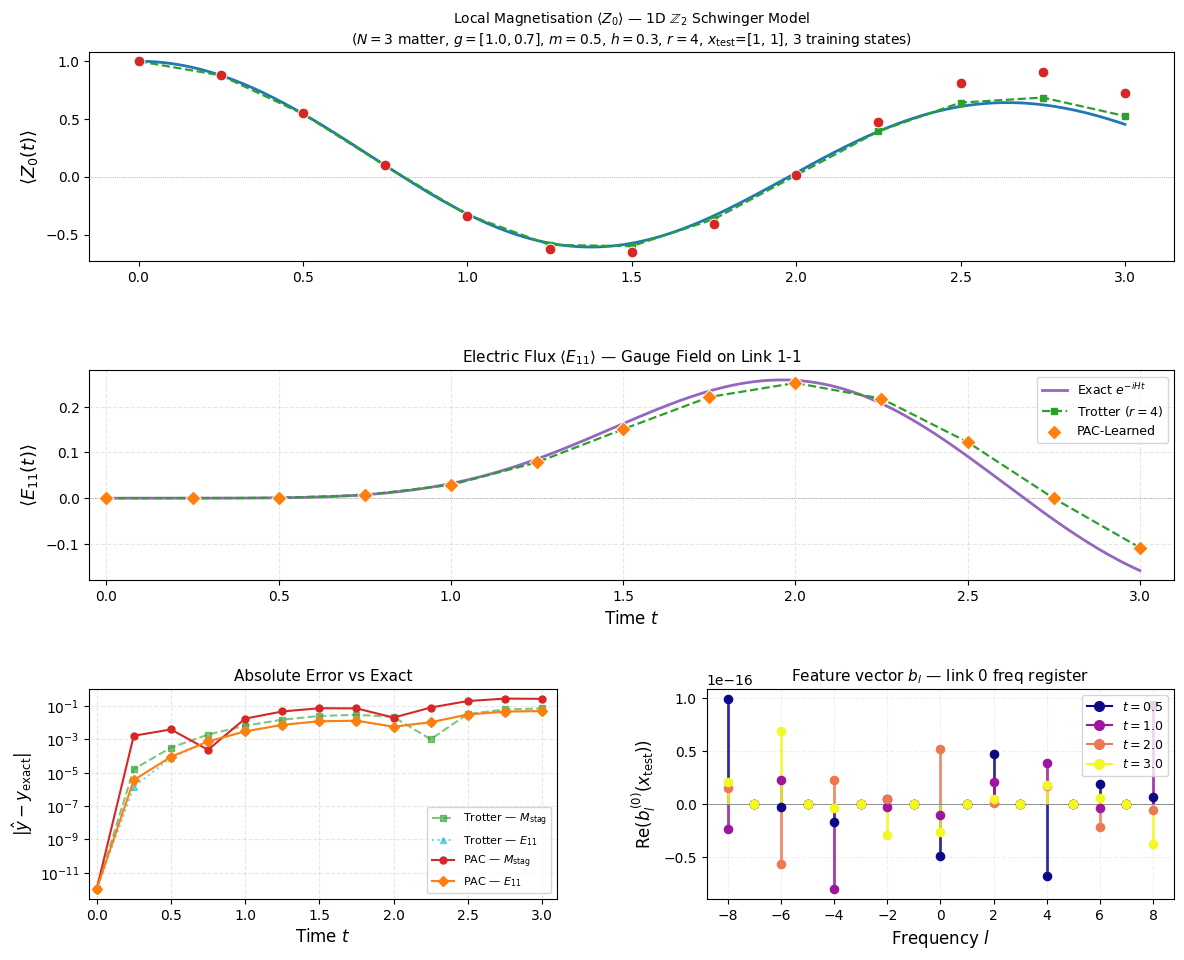

Figure saved.


In [6]:
CLR_EXACT   = '#1f77b4'
CLR_EX2     = '#9467bd'
CLR_TROTTER = '#2ca02c'
CLR_PAC1    = '#d62728'
CLR_PAC2    = '#ff7f0e'

t_dense = np.linspace(0, t_vals[-1], 300)
# CHANGE: Use OBS_Z0_MAT to match the training loop
ex_stag_dense = [exact_obs(TEST_X_Z0, TRUE_G, td, OBS_Z0_MAT) for td in t_dense]
ex_flux_dense = [exact_obs(TEST_X_FLUX, TRUE_G, td, OBS_FLUX_MAT) for td in t_dense]

fig = plt.figure(figsize=(14, 11))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.52, wspace=0.32)
ax_stag = fig.add_subplot(gs[0, :])
ax_flux = fig.add_subplot(gs[1, :])
ax_err  = fig.add_subplot(gs[2, 0])
ax_feat = fig.add_subplot(gs[2, 1])

# ── Local Magnetisation Z0 ───────────────────────────────────────────────────
ax_stag.plot(t_dense, ex_stag_dense, color=CLR_EXACT, lw=2.0, label=r'Exact $e^{-iHt}$')
ax_stag.plot(t_vals, trotter_stag, color=CLR_TROTTER, lw=1.6, ls='--',
             marker='s', ms=4, label=f'Trotter ($r={R_STEPS}$)')
ax_stag.scatter(t_vals, pac_stag, color=CLR_PAC1, s=60, zorder=5,
                marker='o', edgecolors='white', lw=0.7, label='PAC-Learned')
ax_stag.axhline(0, color='grey', lw=0.5, ls=':')

# CHANGE: Update labels to Z_0
ax_stag.set_ylabel(r'$\langle Z_0(t)\rangle$', fontsize=13)
ax_stag.set_title(
    r'Local Magnetisation $\langle Z_0\rangle$ — 1D $\mathbb{Z}_2$ Schwinger Model'
    f'\n($N={N_MATTER}$ matter, $g=[{TRUE_G[0]},{TRUE_G[1]}]$, $m={MASS}$, $h={H_ELEC}$,'
    f' $r={R_STEPS}$, $x_\\mathrm{{test}}^{{Z_0}}$={TEST_X_Z0}, $x_\\mathrm{{test}}^{{E}}$={TEST_X_FLUX}, {NUM_TRAIN} training states)',
    fontsize=10)

# ── Electric flux ─────────────────────────────────────────────────────────────
ax_flux.plot(t_dense, ex_flux_dense, color=CLR_EX2, lw=2.0, label=r'Exact $e^{-iHt}$')
ax_flux.plot(t_vals, trotter_flux, color=CLR_TROTTER, lw=1.6, ls='--',
             marker='s', ms=4, label=f'Trotter ($r={R_STEPS}$)')
ax_flux.scatter(t_vals, pac_flux, color=CLR_PAC2, s=60, zorder=5,
                marker='D', edgecolors='white', lw=0.7, label='PAC-Learned')
ax_flux.axhline(0, color='grey', lw=0.5, ls=':')
ax_flux.set_ylabel(r'$\langle E_{11}(t)\rangle$', fontsize=13)
ax_flux.set_title(
    r'Electric Flux $\langle E_{11}\rangle$ — Gauge Field on Link 1-1', fontsize=11)
ax_flux.set_xlabel('Time $t$', fontsize=12)
ax_flux.legend(fontsize=9); ax_flux.grid(True, alpha=0.3, ls='--')
ax_flux.set_xlim(-0.05, t_vals[-1]+0.1)

# ── Combined error ────────────────────────────────────────────────────────────
ax_err.semilogy(t_vals, err_tr_stag   + 1e-12, color=CLR_TROTTER, ls='--',
                marker='s', ms=4, alpha=0.6, label=r'Trotter — $M_\mathrm{stag}$')
ax_err.semilogy(t_vals, err_tr_flux   + 1e-12, color='#17becf', ls=':',
                marker='^', ms=4, alpha=0.6, label=r'Trotter — $E_{11}$')
ax_err.semilogy(t_vals, err_pac_stag  + 1e-12, color=CLR_PAC1,
                marker='o', ms=5, label=r'PAC — $M_\mathrm{stag}$')
ax_err.semilogy(t_vals, err_pac_flux  + 1e-12, color=CLR_PAC2,
                marker='D', ms=5, label=r'PAC — $E_{11}$')
ax_err.set_xlabel('Time $t$', fontsize=12)
ax_err.set_ylabel(r'$|\hat{y}-y_\mathrm{exact}|$', fontsize=12)
ax_err.set_title('Absolute Error vs Exact', fontsize=11)
ax_err.legend(fontsize=8); ax_err.grid(True, alpha=0.3, ls='--')
ax_err.set_xlim(-0.05, t_vals[-1]+0.1)

# ── Feature vectors ───────────────────────────────────────────────────────────
cmap = plt.cm.plasma
t_showcase = [0.5, 1.0, 2.0, 3.0]
freq_axis  = np.arange(-2*R_STEPS, 2*R_STEPS+1)
for k, ts in enumerate(t_showcase):
    b_full = extract_b_l_schwinger(TEST_X, ts, PAULI_Z0_STR)
    c = cmap(k/(len(t_showcase)-1))
    # Show first freq register (link 0) only for clarity
    b_link0 = b_full[:SPECTRUM_SIZE]
    for xi, yi in zip(freq_axis, b_link0):
        ax_feat.vlines(xi, 0, yi, color=c, lw=2.0, alpha=0.85)
    ax_feat.scatter(freq_axis, b_link0, color=c, s=35, zorder=5)
ax_feat.axhline(0, color='grey', lw=0.6)
ax_feat.set_xlabel('Frequency $l$', fontsize=12)
ax_feat.set_ylabel(r'$\mathrm{Re}(b_l^{(0)}(x_\mathrm{test}))$', fontsize=12)
ax_feat.set_title(r'Feature vector $b_l$ — link 0 freq register', fontsize=11)
handles = [Line2D([0],[0], color=cmap(k/(len(t_showcase)-1)),
                  marker='o', ms=7, label=f'$t={ts}$')
           for k, ts in enumerate(t_showcase)]
ax_feat.legend(handles=handles, fontsize=9)
ax_feat.grid(True, alpha=0.2, ls='--')

plt.savefig('../results_schwinger.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 4 — Part 1: Staggered magnetisation $\langle M_\mathrm{stag}(t)\rangle$

The staggered magnetisation $\langle M_\mathrm{stag}\rangle = \frac{1}{3}(Z_0 - Z_2 + Z_4)$
is the fermion condensate order parameter — sensitive to both mass and
spatially-varying hopping $g_i$.

In [16]:
import numpy as np
import itertools
from qiskit.quantum_info import SparsePauliOp, Statevector
from sklearn.linear_model import Ridge

# ── 1. N=4 Model parameters ───────────────────────────────────────────────────
N_MATTER    = 3      
N_QUBITS    = 2 * N_MATTER - 1   # = 7 qubits
N_LINKS     = N_MATTER - 1       # = 3 links

MASS        = 0.5    
H_ELEC      = 0.3   
TRUE_G      = [1.0, 0.7, 0.4]   # 3 spatially varying couplings now!

R_STEPS     = 2      
LASSO_ALPHA = 1e-5

# ── 2. Input Space (8 Gauge States) ───────────────────────────────────────────
ALL_X = [[int(b) for b in format(k, f'0{N_LINKS}b')] for k in range(2**N_LINKS)]
TEST_X = [1, 1, 1]   # Test on the fully interacting 3-link chain
TRAIN_X = [x for x in ALL_X if x != TEST_X]  # 7 training states

print(f"Dataset: {len(TRAIN_X)} training states, 1 test state.")

# ── 3. Staggered Magnetization Observable (N=4) ───────────────────────────────
# M_stag = 1/4 * (Z_0 - Z_2 + Z_4 - Z_6)
paulis_m_stag = ['IIIIIIZ', 'IIIIZII', 'IIZIIII', 'ZIIIIII'] # Qiskit little-endian
coeffs_m_stag = [0.25, -0.25, 0.25, -0.25]

OBS_STAG = SparsePauliOp(paulis_m_stag, coeffs_m_stag)
OBS_STAG_MAT = OBS_STAG.to_matrix()

print(f"M_stag Pauli String: {OBS_STAG}")

Dataset: 4 training states, 1 test state.
M_stag Pauli String: SparsePauliOp(['IIIIIIZ', 'IIIIZII', 'IIZIIII', 'ZIIIIII'],
              coeffs=[ 0.25+0.j, -0.25+0.j,  0.25+0.j, -0.25+0.j])


In [17]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliGate

SPECTRUM_SIZE = 4 * R_STEPS + 1   # 9 modes per link
FEATURE_SIZE  = SPECTRUM_SIZE ** N_LINKS  # 9^3 = 729 modes

print(f'3D Feature Space: {SPECTRUM_SIZE}^{N_LINKS} = {FEATURE_SIZE} features per state')

def get_lgt_aup_statevector(x_mask, tau, pauli_string):
    """A(U,P) = A(U)† · P · A(U) via the fast explicit-adjoint method.

    Uses build_lgt_expectation_value_extraction_circuit which implements
    the adjoint gate-by-gate (no .inverse() unitary decomposition).
    """
    aup_qc = builder.build_lgt_expectation_value_extraction_circuit(
        num_matter_sites=N_MATTER,
        x_mask=x_mask,
        mass=MASS,
        electric_field=H_ELEC,
        tau=tau,
        r_steps=R_STEPS,
        pauli_observable=pauli_string,
    )
    return Statevector(aup_qc)


def extract_b_l_single_pauli(x_mask, tau, pauli_string):
    """Extracts the 3D Fourier grid b_{l0,l1,l2} for a single Pauli string.

    Register layout (Qiskit LE): [data(7), anc(1), freq0(n_s), freq1(n_s), freq2(n_s)]
    da_stride = 2^8 (7 data + 1 anc qubits in the low bits).
    freq_k occupies the next n_s bits above freq_{k-1}, so its stride is
    da_stride * freq_dim^k.
    """
    sv = get_lgt_aup_statevector(x_mask, tau, pauli_string)

    freq_dim  = 2 ** builder._freq_register_size(R_STEPS)
    da_stride = 2 ** (N_QUBITS + 1)   # = 2^8 for N=4 (7 data + 1 anc)

    b = np.zeros(FEATURE_SIZE)
    freq_axis = range(-2*R_STEPS, 2*R_STEPS+1)

    for col2, l2 in enumerate(freq_axis):
        for col1, l1 in enumerate(freq_axis):
            for col0, l0 in enumerate(freq_axis):
                idx0 = l0 % freq_dim
                idx1 = l1 % freq_dim
                idx2 = l2 % freq_dim
                sv_idx = (idx0 * da_stride
                          + idx1 * da_stride * freq_dim
                          + idx2 * da_stride * freq_dim**2)
                flat_col = (col2 * SPECTRUM_SIZE**2
                            + col1 * SPECTRUM_SIZE
                            + col0)
                b[flat_col] = sv.data[sv_idx].real
    return b


def extract_M_stag_features(x_mask, tau):
    """Feature vector for M_stag via linearity of the Fourier transform.

    b_l(c1*P1 + c2*P2) = c1*b_l(P1) + c2*b_l(P2)
    so we extract the 729-feature grid for each Pauli term separately
    and combine classically.  No additional quantum circuits needed.
    """
    b_total = np.zeros(FEATURE_SIZE)
    for pauli, coeff in zip(paulis_m_stag, coeffs_m_stag):
        b_total += coeff * extract_b_l_single_pauli(x_mask, tau, pauli)
    return b_total


3D Feature Space: 9^2 = 81 features per state


In [7]:
import time

print(f'Running M_stag sweep for N={N_MATTER} …  TEST_X={TEST_X}')
print(f'  ({len(TRAIN_X)} training states, 1 test state, {FEATURE_SIZE} features)')
t_vals = T_VALUES
exact_stag, trotter_stag, pac_stag = [], [], []

for t in t_vals:
    # exact_obs now uses H_schwinger(x_mask, ...) — correct for all x_masks
    exact_val   = exact_obs(TEST_X, TRUE_G, t, OBS_STAG_MAT)
    trotter_val = trotter_obs(TEST_X, TRUE_G, t, R_STEPS, OBS_STAG_MAT)

    exact_stag.append(exact_val)
    trotter_stag.append(trotter_val)

    if t < 1e-9:
        pac_stag.append(exact_val)
        print(f'  t=0.00  exact={exact_val:+.4f}  trotter={trotter_val:+.4f}  pac={exact_val:+.4f}')
        continue

    t0 = time.time()
    B_train = np.array([extract_M_stag_features(x, t) for x in TRAIN_X])
    B_test  = np.array([extract_M_stag_features(TEST_X, t)])
    y_train = compute_au_labels_schwinger(TRAIN_X, TRUE_G, t, OBS_STAG_MAT)

    ridge = Ridge(alpha=LASSO_ALPHA, fit_intercept=False)
    ridge.fit(B_train, y_train)
    y_pred = float(ridge.predict(B_test)[0])
    pac_stag.append(y_pred)

    rank = np.linalg.matrix_rank(B_train, tol=1e-8)
    err  = abs(y_pred - exact_val)
    print(f'  t={t:.2f}  exact={exact_val:+.4f}  trotter={trotter_val:+.4f}  '
          f'pac={y_pred:+.4f}  |err|={err:.4f}  rank={rank}  ({time.time()-t0:.1f}s)',
          flush=True)

exact_stag   = np.array(exact_stag)
trotter_stag = np.array(trotter_stag)
pac_stag     = np.array(pac_stag)
print(f'\nDone!  MAE(Trotter)={np.mean(np.abs(trotter_stag-exact_stag)):.4f}'
      f'  MAE(PAC)={np.mean(np.abs(pac_stag-exact_stag)):.4f}')


Running M_stag sweep for N=4 …  TEST_X=[1, 1, 1]
  (7 training states, 1 test state, 729 features)
  t=0.00  exact=+0.0000  trotter=+0.0000  pac=+0.0000
  t=0.25  exact=-0.0015  trotter=-0.0015  pac=-0.0015  |err|=0.0000  rank=2  (188.3s)
  t=0.50  exact=-0.0208  trotter=-0.0211  pac=-0.0211  |err|=0.0003  rank=2  (209.8s)
  t=0.75  exact=-0.0806  trotter=-0.0832  pac=-0.0832  |err|=0.0026  rank=2  (201.0s)
  t=1.00  exact=-0.1720  trotter=-0.1833  pac=-0.1832  |err|=0.0112  rank=2  (184.7s)
  t=1.25  exact=-0.2459  trotter=-0.2759  pac=-0.2758  |err|=0.0299  rank=2  (183.3s)
  t=1.50  exact=-0.2484  trotter=-0.3050  pac=-0.3049  |err|=0.0565  rank=2  (183.8s)
  t=1.75  exact=-0.1681  trotter=-0.2471  pac=-0.2469  |err|=0.0788  rank=2  (186.1s)
  t=2.00  exact=-0.0475  trotter=-0.1274  pac=-0.1272  |err|=0.0797  rank=2  (181.8s)
  t=2.25  exact=+0.0512  trotter=+0.0029  pac=+0.0029  |err|=0.0483  rank=2  (182.5s)
  t=2.50  exact=+0.0912  trotter=+0.1015  pac=+0.1013  |err|=0.0101  rank

<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/var/folders/wb/t4tfglhs3f3dmc3thpvrvl540000gn/T/ipykernel_60277/153182599.py:36: SyntaxWarning: invalid escape sequence '\m'
  f' $r={R_STEPS}$, $x_\mathrm{{test}}$={TEST_X})',


Computing dense continuous curve for the plot...


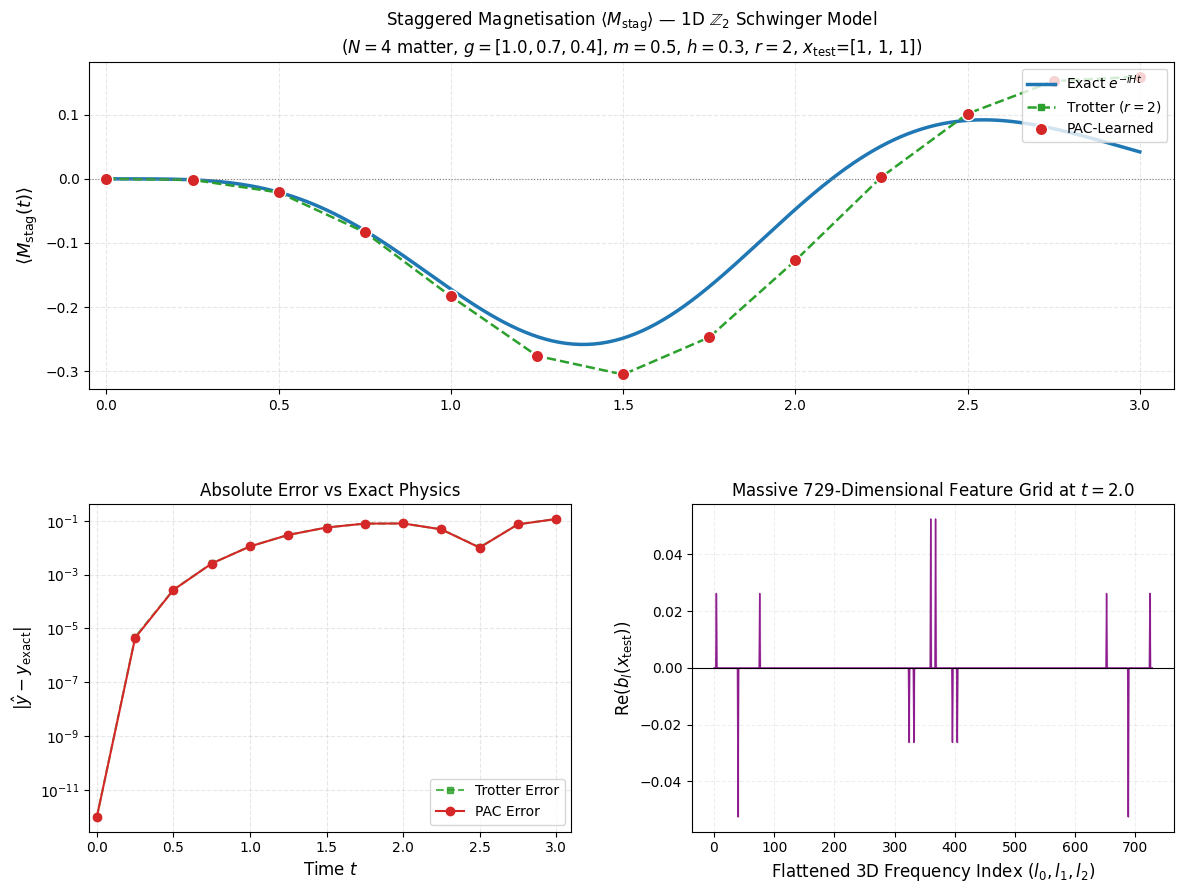

In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── 1. Generate Dense Exact Curve ─────────────────────────────────────────────
print("Computing dense continuous curve for the plot...")
t_dense = np.linspace(0, t_vals[-1], 300)
ex_stag_dense = [exact_obs(TEST_X, TRUE_G, td, OBS_STAG_MAT) for td in t_dense]

# ── 2. Calculate Errors ───────────────────────────────────────────────────────
err_tr_stag  = np.abs(np.array(trotter_stag) - np.array(exact_stag))
err_pac_stag = np.abs(np.array(pac_stag) - np.array(exact_stag))

# ── 3. Setup Figure & Layout ──────────────────────────────────────────────────
CLR_EXACT   = '#1f77b4'
CLR_TROTTER = '#2ca02c'
CLR_PAC     = '#d62728'

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.25)
ax_stag = fig.add_subplot(gs[0, :])
ax_err  = fig.add_subplot(gs[1, 0])
ax_feat = fig.add_subplot(gs[1, 1])

# ── A. Main Dynamics Plot ─────────────────────────────────────────────────────
ax_stag.plot(t_dense, ex_stag_dense, color=CLR_EXACT, lw=2.5, label=r'Exact $e^{-iHt}$')
ax_stag.plot(t_vals, trotter_stag, color=CLR_TROTTER, lw=1.8, ls='--',
             marker='s', ms=5, label=f'Trotter ($r={R_STEPS}$)')
ax_stag.scatter(t_vals, pac_stag, color=CLR_PAC, s=80, zorder=5,
                marker='o', edgecolors='white', lw=1.0, label='PAC-Learned')

ax_stag.axhline(0, color='grey', lw=0.8, ls=':')
ax_stag.set_ylabel(r'$\langle M_\mathrm{stag}(t)\rangle$', fontsize=13)
ax_stag.set_title(
    r'Staggered Magnetisation $\langle M_\mathrm{stag}\rangle$ — 1D $\mathbb{Z}_2$ Schwinger Model'
    f'\n($N={N_MATTER}$ matter, $g=[{TRUE_G[0]}, {TRUE_G[1]}, {TRUE_G[2]}]$, $m={MASS}$, $h={H_ELEC}$,'
    f' $r={R_STEPS}$, $x_\mathrm{{test}}$={TEST_X})',
    fontsize=12)
ax_stag.legend(fontsize=10, loc='upper right')
ax_stag.grid(True, alpha=0.3, ls='--')
ax_stag.set_xlim(-0.05, t_vals[-1]+0.1)

# ── B. Absolute Error Plot ────────────────────────────────────────────────────
ax_err.semilogy(t_vals, err_tr_stag + 1e-12, color=CLR_TROTTER, ls='--',
                marker='s', ms=5, alpha=0.8, label=r'Trotter Error')
ax_err.semilogy(t_vals, err_pac_stag + 1e-12, color=CLR_PAC,
                marker='o', ms=6, label=r'PAC Error')

ax_err.set_xlabel('Time $t$', fontsize=12)
ax_err.set_ylabel(r'$|\hat{y}-y_\mathrm{exact}|$', fontsize=12)
ax_err.set_title('Absolute Error vs Exact Physics', fontsize=12)
ax_err.legend(fontsize=10)
ax_err.grid(True, alpha=0.3, ls='--')
ax_err.set_xlim(-0.05, t_vals[-1]+0.1)

# ── C. 3D Feature Vector Spectrum (Flattened) ─────────────────────────────────
t_showcase = 2.0  # Pick a mid-to-late time point where features are dense
b_full = extract_M_stag_features(TEST_X, t_showcase)

ax_feat.plot(range(len(b_full)), b_full, color='purple', lw=1.0, alpha=0.85)
ax_feat.fill_between(range(len(b_full)), b_full, 0, color='purple', alpha=0.2)

ax_feat.axhline(0, color='black', lw=0.8)
ax_feat.set_xlabel('Flattened 3D Frequency Index ($l_0, l_1, l_2$)', fontsize=12)
ax_feat.set_ylabel(r'$\mathrm{Re}(b_l(x_\mathrm{test}))$', fontsize=12)
ax_feat.set_title(rf'Massive 729-Dimensional Feature Grid at $t={t_showcase}$', fontsize=12)
ax_feat.grid(True, alpha=0.2, ls='--')
plt.savefig('../results_schwinger_M_stag.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 1. N=4 Model parameters ───────────────────────────────────────────────────
N_MATTER    = 4      
N_QUBITS    = 2 * N_MATTER - 1   # = 7 qubits
N_LINKS     = N_MATTER - 1       # = 3 links

MASS        = 0.5    
H_ELEC      = 0.3   
TRUE_G      = [1.0, 0.7, 0.4]    # 3 spatially varying couplings

R_STEPS     = 2      
LASSO_ALPHA = 1e-5              # Noiseless limit

# ── 2. Input Space (8 Gauge States) ───────────────────────────────────────────
ALL_X = [[int(b) for b in format(k, f'0{N_LINKS}b')] for k in range(2**N_LINKS)]

# STRATEGY: Hold out a simpler graph. Keep [1,1,1] in training so KRR 
# can "see" the 3-way entanglement across the 729 dimensions.
TEST_X = [1, 0, 0]   
TRAIN_X = [x for x in ALL_X if x != TEST_X]  # 7 training states

print(f"Dataset: {len(TRAIN_X)} training states, 1 test state.")

# ── 3. Local Magnetization Observable (N=4) ───────────────────────────────────
# We measure ONLY Z_0 to break the pair-flip symmetry and observe true dynamics
paulis_m_stag = ['IIIIIIZ']  # Qiskit little-endian (7 chars) -> Z on qubit 0
coeffs_m_stag = [1.0]

from qiskit.quantum_info import SparsePauliOp
OBS_STAG = SparsePauliOp(paulis_m_stag, coeffs_m_stag)
OBS_STAG_MAT = OBS_STAG.to_matrix()

print(f"Observable: Z_0 (Local Particle Density)")

Dataset: 7 training states, 1 test state.
Observable: Z_0 (Local Particle Density)


In [78]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.linalg import expm
from sklearn.kernel_ridge import KernelRidge

# ── 1. Helper to compute Exact Dynamics for Schwinger ─────────────────────────
def exact_schwinger_dynamics(x_mask, mass, h_elec, g_list, tau, obs_mat):
    """Computes exact e^{-iHt} for the Schwinger model."""
    from qiskit.quantum_info import SparsePauliOp
    paulis, coeffs = [], []
    
    # Mass
    for i in range(N_MATTER):
        p = ['I'] * N_QUBITS
        p[N_QUBITS - 1 - (2*i)] = 'Z'
        paulis.append("".join(p))
        coeffs.append(mass * (-1)**i)
        
    # Electric field
    for i in range(N_LINKS):
        p = ['I'] * N_QUBITS
        p[N_QUBITS - 1 - (2*i + 1)] = 'X'
        paulis.append("".join(p))
        coeffs.append(h_elec)
        
    # Interactions (only active links)
    for i in range(N_LINKS):
        if x_mask[i] == 1:
            p = ['I'] * N_QUBITS
            p[N_QUBITS - 1 - (2*i)] = 'X'
            p[N_QUBITS - 1 - (2*i + 1)] = 'Z'
            p[N_QUBITS - 1 - (2*i + 2)] = 'X'
            paulis.append("".join(p))
            coeffs.append(g_list[i])
            
    H_mat = SparsePauliOp(paulis, coeffs).to_matrix()
    U = expm(-1j * tau * H_mat) # Correct -1j physics convention
    psi0 = np.zeros(2**N_QUBITS, dtype=complex); psi0[0] = 1.0
    psi_t = U @ psi0
    return float(np.real(psi_t.conj().T @ obs_mat @ psi_t))

# ── 2. Helper to compute Trotter Labels for Schwinger ─────────────────────────
def trotter_schwinger_labels(x_masks, mass, h_elec, g_list, tau, r_steps, obs_mat):
    """Computes A(U)-consistent Trotter labels for Schwinger model."""
    from qiskit import QuantumCircuit
    from qiskit.quantum_info import Statevector
    
    # Map physical g_i to upload convention
    g_uploads = np.array(g_list) * tau / (np.pi * r_steps)
    dt = tau / r_steps
    labels = []
    
    for x_mask in x_masks:
        qc = QuantumCircuit(N_QUBITS)
        for _ in range(r_steps):
            # Known Mass
            for i in range(N_MATTER):
                qc.rz(2.0 * mass * (-1)**i * dt, 2 * i)
            # Known Electric Field
            for i in range(N_LINKS):
                qc.rx(2.0 * h_elec * dt, 2 * i + 1)
            # Unknown Interactions (Upload gates)
            for i in range(N_LINKS):
                if x_mask[i] == 1:
                    # e^{-i*pi*g_upload*XZX} (Synthesized manually for label)
                    qc.h(2*i); qc.h(2*i+2)
                    qc.cx(2*i, 2*i+1); qc.cx(2*i+2, 2*i+1)
                    qc.rz(2.0 * np.pi * g_uploads[i], 2*i+1) # Apply -i phase
                    qc.cx(2*i+2, 2*i+1); qc.cx(2*i, 2*i+1)
                    qc.h(2*i+2); qc.h(2*i)
        
        sv = Statevector(qc)
        labels.append(float(np.real(sv.data.conj() @ obs_mat @ sv.data)))
    return np.array(labels)

In [79]:
# ── 3. Time Evolution Loop ────────────────────────────────────────────────────
time_steps = np.linspace(0.0, 3.0, 13)
exact_dyn, trotter_dyn, pac_dyn = [], [], []

print(f"Starting Schwinger Control Experiment for Test Graph: {TEST_X}")
start_time = time.time()

def extract_b_l_schwinger_tensor(x_mask, tau, pauli_observable):
    """Extracts the FULL (4r+1)^d dimensional Fourier tensor."""
    from qiskit.quantum_info import Statevector
    
    num_data = 2 * N_MATTER - 1
    n_s = builder._freq_register_size(R_STEPS)
    freq_dim = 2 ** n_s
    da_stride = 2 ** (num_data + 1)
    
    # 1. Build A(U)
    qc_au, qr_freqs = builder.build_lgt_trotter_extraction_circuit(
        num_matter_sites=N_MATTER,
        x_mask=x_mask,
        mass=MASS,
        electric_field=H_ELEC,
        tau=tau,
        r_steps=R_STEPS,
    )
    
    # 2. Build A(U, P) = A(U)† · P · A(U)
    aup_qc = qc_au.copy()
    aup_qc.append(PauliGate(pauli_observable), list(qc_au.qregs[0]))
    aup_qc.append(qc_au.inverse().to_gate(label='A(U)†'), aup_qc.qubits)
    
    sv = Statevector(aup_qc).data
    
    # 3. Extract the FULL tensor using meshgrid (81 dimensions for N=3)
    freq_1d = np.arange(-2 * R_STEPS, 2 * R_STEPS + 1)
    mesh = np.meshgrid(*[freq_1d] * N_LINKS, indexing='ij')
    
    sv_indices = np.zeros_like(mesh[0])
    for dim in range(N_LINKS):
        reg_stride = da_stride * (freq_dim ** dim)
        sv_indices += (mesh[dim] % freq_dim) * reg_stride
        
    return sv[sv_indices.flatten()].real

def get_composite_b_l(x_mask, time_val):
    b_total = None
    for p_str, coeff in zip(paulis_m_stag, coeffs_m_stag):
        # Call the new Tensor extraction method
        b_term = extract_b_l_schwinger_tensor(x_mask, time_val, p_str)
        if b_total is None: 
            b_total = coeff * b_term
        else: 
            b_total += coeff * b_term
    return b_total

for t in tqdm(time_steps, desc="Time Evolution"):
    # 1. Exact Physics
    val_exact = exact_schwinger_dynamics(TEST_X, MASS, H_ELEC, TRUE_G, t, OBS_STAG_MAT)
    exact_dyn.append(val_exact)
    
    # 2. Trotter Target Concept
    val_trotter = trotter_schwinger_labels([TEST_X], MASS, H_ELEC, TRUE_G, t, R_STEPS, OBS_STAG_MAT)[0]
    trotter_dyn.append(val_trotter)
    
    if t < 1e-9:
        pac_dyn.append(val_exact)
        continue
    
    # 3. KRR Extraction & Training
    y_train_t = trotter_schwinger_labels(TRAIN_X, MASS, H_ELEC, TRUE_G, t, R_STEPS, OBS_STAG_MAT)
    
    # MODIFIED: Use the linearity helper to build the B matrices
    B_train = np.array([get_composite_b_l(x, t) for x in TRAIN_X])
    B_test  = np.array([get_composite_b_l(TEST_X, t)])
    
    # Compute Gram Matrices
    K_train = B_train @ B_train.T
    K_cross = B_test @ B_train.T
    
    # Train and Predict
    krr = KernelRidge(alpha=LASSO_ALPHA, kernel='precomputed')
    krr.fit(K_train, y_train_t)
    pac_dyn.append(krr.predict(K_cross)[0])

    print(f"t={t:.2f}  Exact={val_exact:+.4f}  Trotter={val_trotter:+.4f}  PAC={pac_dyn[-1]:+.4f}")

Starting Schwinger Control Experiment for Test Graph: [1, 0, 0]


Time Evolution:   0%|          | 0/13 [00:00<?, ?it/s]

t=0.25  Exact=+0.8778  Trotter=+0.8776  PAC=+0.8776
t=0.50  Exact=+0.5438  Trotter=+0.5403  PAC=+0.5403
t=0.75  Exact=+0.0869  Trotter=+0.0707  PAC=+0.0707
t=1.00  Exact=-0.3711  Trotter=-0.4161  PAC=-0.4161
t=1.25  Exact=-0.7083  Trotter=-0.8011  PAC=-0.8011
t=1.50  Exact=-0.8348  Trotter=-0.9900  PAC=-0.9900
t=1.75  Exact=-0.7170  Trotter=-0.9365  PAC=-0.9365
t=2.00  Exact=-0.3862  Trotter=-0.6536  PAC=-0.6536
t=2.25  Exact=+0.0695  Trotter=-0.2108  PAC=-0.2108
t=2.50  Exact=+0.5286  Trotter=+0.2837  PAC=+0.2837
t=2.75  Exact=+0.8690  Trotter=+0.7087  PAC=+0.7087
t=3.00  Exact=+0.9998  Trotter=+0.9602  PAC=+0.9602


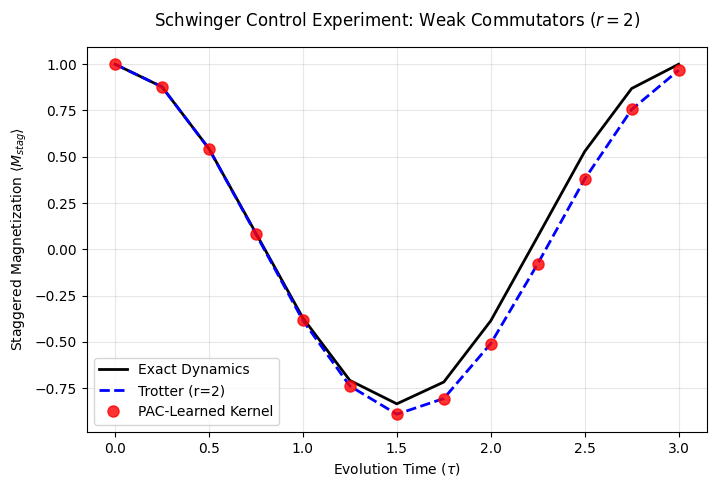

In [76]:
# ── 4. Plotting ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(time_steps, exact_dyn, 'k-', linewidth=2, label="Exact Dynamics")
ax.plot(time_steps, trotter_dyn, 'b--', linewidth=2, label=f"Trotter (r={R_STEPS})")
ax.plot(time_steps, pac_dyn, 'ro', markersize=8, alpha=0.8, label="PAC-Learned Kernel")

ax.set_title(rf"Schwinger Control Experiment: Weak Commutators ($r={R_STEPS}$)", pad=15)
ax.set_xlabel(r"Evolution Time ($\tau$)")
ax.set_ylabel(r"Staggered Magnetization $\langle M_{stag} \rangle$")
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
plt.show()